In [1]:
from executor import Executor, QuantumCircuit, QuantumOperator, Parameters
%matplotlib inline

In [2]:
x = Parameters("x", 1)
p = Parameters("p", 2)

qc = QuantumCircuit(2)
qc.h(0)
qc.cry(0, 1, p[0] * x[0])

In [3]:
pop = Parameters("pop", 2)
operator = QuantumOperator(["ZI", "IZ"], [pop[0], pop[1]])

SparsePauliOp(['ZI', 'IZ'],
              coeffs=[<qiskit._accelerate.circuit.ParameterExpression object at 0x000001D001860B70>,
 <qiskit._accelerate.circuit.ParameterExpression object at 0x000001D001860C30>])


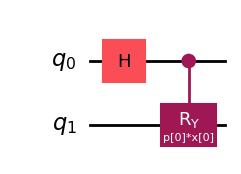

In [4]:
executor = Executor.create("qiskit", seed=0, shots=10000)

qiskit_circuit = executor.transpile_circuit(qc)
qiskit_circuit.qiskit_circuit.draw("mpl")

qiskit_operator = executor.transpile_observable(operator)
print(qiskit_operator.qiskit_operator)

In [5]:
result = executor.expectation_value(
    qiskit_circuit,
    qiskit_operator,
    x=[0.1],
    p=[0.3],
    pop=[0.5, 0.6],
)
print("Expectation value:", result)

Expectation value: 0.507373046875


In [6]:
v = executor.expectation_value_derivatives(
    qiskit_circuit,
    qiskit_operator,
    "x",
    "p",
    "pop",
    x=[0.1],
    p=[0.3],
    pop=[0.5, 0.6],
)
print(v)

{'x': np.float64(-0.001007080078125), 'p': np.float64(-0.00085693359375)}


In [7]:
executor.statevector(
    qiskit_circuit,
    x=[0.8],
    p=[0.5],
)

array([0.70710678+0.j, 0.69301172+0.j, 0.        +0.j, 0.14048043+0.j])

In [8]:
executor.sample(
    qiskit_circuit,
    x=[0.8],
    p=[0.5],
)

[{'00': 5005, '01': 4823, '11': 172}]